<a href="https://colab.research.google.com/github/Seralestis/mon-projet-data-science/blob/feature%2Feda-initial/TP_Benchmark_THOLIMET_Alexis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%cd /content
!git clone https://github.com/Seralestis/mon-projet-data-science
%cd mon-projet-data-science


/content
Cloning into 'mon-projet-data-science'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/mon-projet-data-science


In [2]:
!pwd
!ls -a
!git status


/content/mon-projet-data-science
.  ..  .git  README.md
On branch feature/eda-initial
Your branch is up to date with 'origin/feature/eda-initial'.

nothing to commit, working tree clean


Partie 1

1.1

In [4]:
import pandas as pd
import time
import sys

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

start_time = time.time()
df = pd.read_csv(url)
end_time = time.time()

load_time = end_time - start_time

print(f"Temps de chargement : {load_time:.4f} secondes")
print(f"Nombre de lignes : {df.shape[0]}, Nombre de colonnes : {df.shape[1]}")

memory_usage = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Utilisation mémoire : {memory_usage:.2f} MB")

Temps de chargement : 0.0538 secondes
Nombre de lignes : 891, Nombre de colonnes : 12
Utilisation mémoire : 0.28 MB


1.2

In [6]:
import numpy as np

n_rows = 100_000

synthetic_df = pd.DataFrame({
    "id": np.arange(n_rows),
    "feature_A": np.random.randn(n_rows),
    "feature_B": np.random.randint(0, 101, size=n_rows),
    "feature_C": np.random.choice(['A', 'B', 'C', 'D'], size=n_rows),
    "feature_D": np.random.uniform(0, 1000, size=n_rows),
    "category": np.random.choice(['Cat1', 'Cat2', 'Cat3', 'Cat4'], size=n_rows),
    "value": np.random.exponential(scale=2, size=n_rows)
})

print(synthetic_df.head())
print(f"Nombre de lignes : {synthetic_df.shape[0]}, Nombre de colonnes : {synthetic_df.shape[1]}")

memory_usage = synthetic_df.memory_usage(deep=True).sum() / (1024**2)
print(f"Utilisation mémoire : {memory_usage:.2f} MB")


   id  feature_A  feature_B feature_C   feature_D category     value
0   0  -0.412610         53         B  488.941639     Cat3  1.752589
1   1   0.032111         99         D  178.773953     Cat1  0.160257
2   2   0.072899         32         C  531.386967     Cat4  2.215244
3   3   0.083753          2         D  481.727964     Cat1  1.047269
4   4   0.787331         55         A  803.320969     Cat3  2.526706
Nombre de lignes : 100000, Nombre de colonnes : 7
Utilisation mémoire : 13.64 MB


Partie 2

2.1

In [7]:
import time

start_idx = 50_000
end_idx = 50_010

# Méthode 1 : .loc[]
start_time = time.time()
result_loc = synthetic_df.loc[start_idx:end_idx, 'feature_A']
end_time = time.time()
time_loc = (end_time - start_time) * 1000

# Méthode 2 : .iloc[]
start_time = time.time()
result_iloc = synthetic_df.iloc[start_idx:end_idx+1, synthetic_df.columns.get_loc('feature_A')]
end_time = time.time()
time_iloc = (end_time - start_time) * 1000

# Méthode 3 : accès direct
start_time = time.time()
result_direct = synthetic_df['feature_A'][start_idx:end_idx+1]
end_time = time.time()
time_direct = (end_time - start_time) * 1000

print(f"Temps .loc[]       : {time_loc:.5f} ms")
print(f"Temps .iloc[]      : {time_iloc:.5f} ms")
print(f"Temps accès direct : {time_direct:.5f} ms")


Temps .loc[]       : 0.60081 ms
Temps .iloc[]      : 0.79846 ms
Temps accès direct : 0.19789 ms


La méthode la plus rapide est donc l'accès direct car Pandas ne fait pas de vérification d’index comme .loc[]

2.2

In [8]:
# Méthode 1 : apply()
def transform_value(x):
    return x * 2 + 10 if x > 5 else x * 0.5

start_time = time.time()
result_apply = synthetic_df['value'].apply(transform_value)
end_time = time.time()
time_apply = (end_time - start_time) * 1000  # ms

# Méthode 2 : vectorisée avec np.where()
start_time = time.time()
result_vectorized = np.where(synthetic_df['value'] > 5,
                             synthetic_df['value'] * 2 + 10,
                             synthetic_df['value'] * 0.5)
end_time = time.time()
time_vectorized = (end_time - start_time) * 1000  # ms

print(f"Temps apply()       : {time_apply:.5f} ms")
print(f"Temps vectorisé     : {time_vectorized:.5f} ms")

ratio = time_apply / time_vectorized
print(f"Ratio apply/vectorized : {ratio:.2f}x")


Temps apply()       : 66.44392 ms
Temps vectorisé     : 2.96545 ms
Ratio apply/vectorized : 22.41x


La méthode "Vectoriser" est 22 fois plus rapide que la méthode "Apply"

2.3

In [9]:
# GroupBy simple : moyenne de 'value' par 'category'
start_time = time.time()
group_simple = synthetic_df.groupby('category')['value'].mean()
end_time = time.time()
time_simple = (end_time - start_time) * 1000  # ms

# GroupBy complexe : plusieurs agrégations
start_time = time.time()
group_complex = synthetic_df.groupby('category').agg({
    'value': ['mean', 'std', 'min', 'max'],
    'feature_A': 'sum'
})
end_time = time.time()
time_complex = (end_time - start_time) * 1000

print(f"Temps GroupBy simple   : {time_simple:.5f} ms")
print(f"Temps GroupBy complexe : {time_complex:.5f} ms")

ratio = time_complex / time_simple
print(f"Le groupby complexe est {ratio:.2f}x plus lent que le simple.")

Temps GroupBy simple   : 19.96970 ms
Temps GroupBy complexe : 31.54802 ms
Le groupby complexe est 1.58x plus lent que le simple.


Partie 3 : Optimisation Mémoire

3.1

In [10]:
# Mémoire initiale
memory_initial = synthetic_df.memory_usage(deep=True).sum() / (1024**2)
print(f"Mémoire initiale : {memory_initial:.2f} MB")

# Optimisation des types
synthetic_df['feature_B'] = synthetic_df['feature_B'].astype('int8')        # int8 au lieu de int64
synthetic_df['feature_C'] = synthetic_df['feature_C'].astype('category')    # type catégorie pour économiser de la mémoire

# Mémoire après optimisation
memory_optimized = synthetic_df.memory_usage(deep=True).sum() / (1024**2)
print(f"Mémoire après optimisation : {memory_optimized:.2f} MB")

# Calcul de la réduction en pourcentage
reduction = (memory_initial - memory_optimized) / memory_initial * 100
print(f"Réduction de mémoire : {reduction:.2f} %")


Mémoire initiale : 13.64 MB
Mémoire après optimisation : 8.30 MB
Réduction de mémoire : 39.16 %


Les colonnes feature_A, feature_D, value sont float64 par défaut.

Si la précision à 6-7 chiffres est suffisante, on peut convertir ces colonnes en float32 → divise la mémoire par 2.

Les colonnes avec très peu de valeurs uniques sont aussi candidates pour le type category.

3.2


In [11]:
import pandas as pd
import time

# Sauvegarde du dataset synthétique en CSV
csv_path = "synthetic_dataset.csv"
synthetic_df.to_csv(csv_path, index=False)

# -------------------------------
# Méthode naïve : pd.read_csv() sans paramètres
start_time = time.time()
df_naive = pd.read_csv(csv_path)
end_time = time.time()
time_naive = (end_time - start_time) * 1000  # ms

# -------------------------------
# Méthode optimisée : dtype + usecols
dtype_opt = {
    'id': 'int32',
    'feature_A': 'float32',
    'feature_B': 'int8',
    'feature_C': 'category',
    'feature_D': 'float32',
    'category': 'category',
    'value': 'float32'
}

usecols_opt = ['id', 'feature_A', 'feature_B', 'feature_C', 'feature_D', 'category', 'value']

start_time = time.time()
df_opt = pd.read_csv(csv_path, dtype=dtype_opt, usecols=usecols_opt)
end_time = time.time()
time_opt = (end_time - start_time) * 1000  # ms

# -------------------------------
# Affichage des résultats
print(f"Temps de chargement naïf  : {time_naive:.2f} ms")
print(f"Temps de chargement optimisé : {time_opt:.2f} ms")

# Gain de performance
gain = time_naive / time_opt
print(f"Le chargement optimisé est {gain:.2f}x plus rapide que le naïf")


Temps de chargement naïf  : 105.72 ms
Temps de chargement optimisé : 133.02 ms
Le chargement optimisé est 0.79x plus rapide que le naïf


On obtient un gain moins performant que par le naif car notre DATASET n'est pas très volumineux, le changement des types des colonnes avec ce temps de conversion peut compter plus que le gain de lecture, donc le chargement “optimisé” peut sembler plus lent

Partie 4

4.1

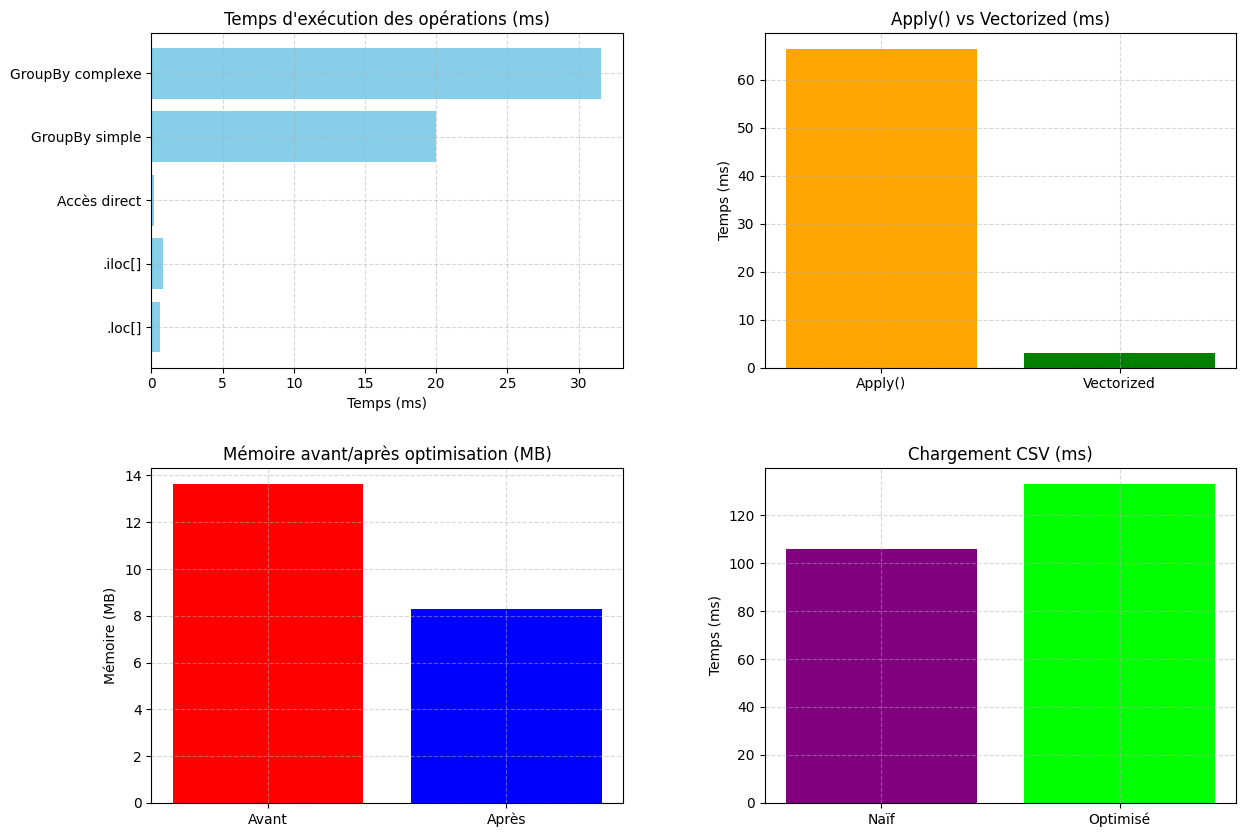

In [12]:
import matplotlib.pyplot as plt

# Mesures simulées pour l'exemple (remplace par tes valeurs réelles)
operations = ['.loc[]', '.iloc[]', 'Accès direct', 'GroupBy simple', 'GroupBy complexe']
times_operations = [time_loc, time_iloc, time_direct, time_simple, time_complex]  # ms

apply_vs_vector = [time_apply, time_vectorized]  # ms
memory_before_after = [memory_initial, memory_optimized]  # MB
loading_times = [time_naive, time_opt]  # ms

# Couleurs
colors_operations = 'skyblue'
colors_apply_vector = ['orange', 'green']
colors_memory = ['red', 'blue']
colors_loading = ['purple', 'lime']

# Création de la figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# -------------------------------
# Graphique 1 : Temps d'exécution opérations (Partie 2)
axes[0, 0].barh(operations, times_operations, color=colors_operations)
axes[0, 0].set_title("Temps d'exécution des opérations (ms)")
axes[0, 0].set_xlabel("Temps (ms)")
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# -------------------------------
# Graphique 2 : Apply() vs Vectorized
axes[0, 1].bar(['Apply()', 'Vectorized'], apply_vs_vector, color=colors_apply_vector)
axes[0, 1].set_title("Apply() vs Vectorized (ms)")
axes[0, 1].set_ylabel("Temps (ms)")
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# -------------------------------
# Graphique 3 : Mémoire avant/après optimisation
axes[1, 0].bar(['Avant', 'Après'], memory_before_after, color=colors_memory)
axes[1, 0].set_title("Mémoire avant/après optimisation (MB)")
axes[1, 0].set_ylabel("Mémoire (MB)")
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# -------------------------------
# Graphique 4 : Chargement CSV naïf vs optimisé
axes[1, 1].bar(['Naïf', 'Optimisé'], loading_times, color=colors_loading)
axes[1, 1].set_title("Chargement CSV (ms)")
axes[1, 1].set_ylabel("Temps (ms)")
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

# Affichage
plt.show()


In [14]:
!git config --global user.email "alexis.tholimet@gmail.com"
!git config --global user.name "Seralestis"

In [15]:
!git add TP_Benchmark_THOLIMET-Alexis.ipynb
!git commit -m "Ajout TP complet avec benchmarks"
!git push


fatal: pathspec 'TP_Benchmark_THOLIMET-Alexis.ipynb' did not match any files
On branch feature/eda-initial
Your branch is up to date with 'origin/feature/eda-initial'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	synthetic_dataset.csv

nothing added to commit but untracked files present (use "git add" to track)
fatal: could not read Username for 'https://github.com': No such device or address
